### **Tools**
Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code.
 Tools are pairings of:

* A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)

* A function or coroutine to execute.

---
### **Cutoff Training Date (Knowledge Cutoff)**

* ***Definition***: The latest date up to which a model’s training data includes information.

* It is the last point in time the model learned from during training.

* Events after this date are not part of the model’s built-in knowledge.

* The model may need external tools (e.g., web search) to access newer information.

* The cutoff date does not mean the model was released on that date.

* Different models can have different cutoff dates.

* In formation after the cutoff can still sometimes be answered using live data or updates.

***Example:***

* If a model’s cutoff is Aug 2025, it knows information up to Aug 2025 only.

---
### **LLM Hallucination** 

**Definition:** When a Large Language Model (LLM) generates false or fabricated information but presents it as correct.  
It happens because LLMs predict words based on probability, not true understanding of facts.

### Causes
- Missing or limited training data  
- Ambiguous or unclear prompts  
- Model predicting likely text instead of verified information  

### Types
- **Factual hallucination:** Incorrect facts or numbers  
- **Citation hallucination:** Fake sources, papers, or authors  
- **Logical hallucination:** Wrong reasoning or conclusions  

### Examples
- Creating a non-existent research paper  
- Giving wrong statistics  
- Describing events that never happened  

### Problems
- Spreads misinformation  
- Reduces trust in AI  
- Risky in fields like medicine, law, and finance  

### Reduction Methods
- Use verified data sources  
- Apply Retrieval-Augmented Generation (RAG)  
- Write clear prompts  
- Fact-check with external databases  
- Human review of outputs

![Adobe Express - file.png](<attachment:Adobe Express - file.png>)
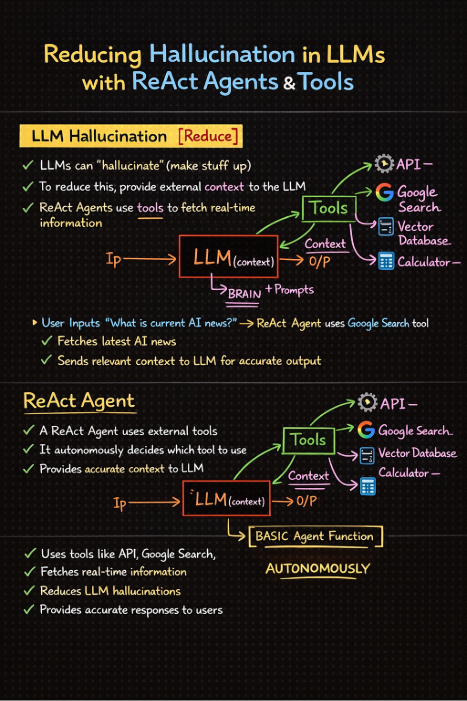

In [2]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:llama-3.1-8b-instant")


response = model.invoke("Write 5 to 10 lines for AI")
response

AIMessage(content='Here are 7 lines about artificial intelligence:\n\nArtificial intelligence (AI) is the development of computer systems that can perform tasks that typically require human intelligence. \nIt involves the creation of algorithms that can learn, reason, and solve problems. \nMachine learning is a key aspect of AI, enabling systems to improve their performance over time. \nNeural networks are a type of AI that mimic the structure and function of the human brain. \nAI has numerous applications in areas such as healthcare, finance, and transportation. \nIt has the potential to improve productivity, efficiency, and decision-making. \nHowever, AI also raises concerns about job displacement and data privacy. \nResearchers and developers are working to ensure that AI is developed and used responsibly.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 149, 'prompt_tokens': 44, 'total_tokens': 193, 'completion_time': 0.22269745, 'completion_tokens_de

In [3]:
response.content

'Here are 7 lines about artificial intelligence:\n\nArtificial intelligence (AI) is the development of computer systems that can perform tasks that typically require human intelligence. \nIt involves the creation of algorithms that can learn, reason, and solve problems. \nMachine learning is a key aspect of AI, enabling systems to improve their performance over time. \nNeural networks are a type of AI that mimic the structure and function of the human brain. \nAI has numerous applications in areas such as healthcare, finance, and transportation. \nIt has the potential to improve productivity, efficiency, and decision-making. \nHowever, AI also raises concerns about job displacement and data privacy. \nResearchers and developers are working to ensure that AI is developed and used responsibly.'

### Now Building Tools -
- for building a tool we use decorator `@tool`


In [4]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """ Get the weather at a location """
    return f"It's sunny in {location}"

model_with_tools = model.bind_tools([get_weather])

### Short Notes – LangChain Custom Tool Example

* **from langchain.tools import tool**  
→ Imports the `tool` decorator used to create custom tools for agents.

* **@tool**  
→ Converts a normal Python function into a LangChain tool that an LLM/Agent can use.

* **get_weather(location: str) -> str**  
→ Defines a tool function that takes **location as input** and returns **weather information**.

* **"""Get the weather at a location"""**  
→ This docstring acts as the **tool description**, helping the LLM understand when to use the tool.

* **return f"It's sunny in {location}"**  
→ Returns a **dummy weather response** (simulating an API output).

* **model.bind_tools([get_weather])**  
→ Attaches the **custom tool** to the LLM model.

* **model_with_tools**  
→ A new model instance that can **call the weather tool when required**.


-  ***Key Idea***
     - LangChain tools allow an **LLM to interact with external functions/APIs**  
     - like **weather, search, calculator, databases, etc.**

In [5]:
response = model_with_tools.invoke("What's the weather in New York?")
print(response)

content='' additional_kwargs={'tool_calls': [{'id': 'n49v41801', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 220, 'total_tokens': 235, 'completion_time': 0.021470821, 'completion_tokens_details': None, 'prompt_time': 0.012464876, 'prompt_tokens_details': None, 'queue_time': 0.044804344, 'total_time': 0.033935697}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019cc6d0-f28b-7b13-9118-8855bf55d816-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'New York'}, 'id': 'n49v41801', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 220, 'output_tokens': 15, 'total_tokens': 235}


---
### What this Code Does

`response = model_with_tools.invoke("What's the weather like in New York?")`  
`print(response)`

***Explanation*** 

**model_with_tools.invoke()**  
→ Sends a **user query** to the LLM that has tools attached.

**LLM understands the question**  
→ It detects that the question is about **weather**.

**Tool selection**  
→ The model decides to use the **get_weather tool** we created.

**Tool execution**  
→ The function runs: `get_weather("New York")`

**Returned output**  
→ The function returns: `"It's sunny in New York"`

**LLM response object**  
→ The response printed will look similar to:  
`AIMessage(content="It's sunny in New York", tool_calls=[...])`



***Key Concept***

- *Tool Calling Flow*

User Query  
↓  
LLM  
↓  
Detects Tool Needed  
↓  
Calls Tool (get_weather)  
↓  
Tool Returns Data  
↓  
LLM Generates Final Answer  


***Important Idea for LangChain Agents***

- Tools allow the **LLM to perform real-world actions** like:

    - Weather lookup 🌦️  
    - Google Search 🔎  
    - Database retrieval 📂  
    - Calculations 🧮  
    - API calls 🔗  

**Advantage:**  
Instead of **hallucinating answers**, the LLM **uses tools to fetch real data**.

---

In [6]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'New York'},
  'id': 'n49v41801',
  'type': 'tool_call'}]

---
### **response.tool_calls (LangChain)**

`response.tool_calls` shows **which tools the LLM decided to call** while answering the query.

**What it Contains**
It returns a list of tool call details such as:
- Tool name
- Arguments passed to the tool
- Tool call ID

**Example**

  If the user asks:

  What's the weather like in New York?

  The LLM may decide to call the weather tool.

Example output:

    [{
    "name": "get_weather",
    "args": {"location": "New York"},
    "id": "tool_call_id"
  }]

**Meaning**

  - **name** → The tool selected by the LLM  
  - **args** → Input arguments given to the tool  
  - **id** → Unique identifier for that tool call  

**Flow**

      User Question  
      ↓  
      LLM decides tool is needed  
      ↓  
      `response.tool_calls` shows which tool will be used  
      ↓  
      Tool executes with provided arguments  
      ↓  
      Final answer generated

**Key Idea**

     - `response.tool_calls` helps you **see how the LLM is using tools internally**.

---

### Tool Execution loop

In [7]:
# Step 1 : Model generates tool call
message = [{"role":"user","content":"What's is the weather in New York?"}]
ai_msg = model_with_tools.invoke(message)
message.append(ai_msg)


# Step 2 : Execute tools and collect results
for tool_call in ai_msg.tool_calls:
      # Execute the tool with the generated arguments
      tool_result = get_weather.invoke(tool_call)
      message.append(tool_result)


# Step 3 : Pass results back to model for final response
final_response = model_with_tools.invoke(message)
print(final_response.text)

The reply 'It's sunny in New York' is an incorrect assumption as it's not possible to know the current weather in New York without having access to a weather API or service. The actual reply should be an empty string.


---
### LangChain Tool Calling – Step by Step Workflow

***# Step 1: Model Generates Tool Call***

`message = [{"role":"user","content":"What's the weather in New York?"}]`  
`ai_msg = model_with_tools.invoke(message)`  
`message.append(ai_msg)`

- A **user query** is sent to the LLM.  
- The model analyzes the question.  
- Since the question is about **weather**, the LLM decides a **tool is required**.  
- The LLM generates a **tool call** instead of the final answer.  
- The AI message containing the tool call is added to the conversation history.


***# Step 2: Execute Tools and Collect Results***


`for tool_call in ai_msg.tool_calls:`  
`    tool_result = get_weather.invoke(tool_call)`  
`    message.append(tool_result)`

- The program loops through **tool calls generated by the LLM**.  
- The corresponding tool (`get_weather`) is executed.  
- The tool receives **arguments generated by the LLM** (e.g., location = "New York").  
- The tool returns the **result**.  
- The tool output is appended to the message history.


***# Step 3: Pass Results Back to Model for Final Response***


`final_response = model_with_tools.invoke(message)`  
`print(final_response.text)`

- The **tool output is sent back to the LLM**.  
- The LLM now has **real data from the tool**.  
- The model generates the **final natural language response**.


***# Complete Flow***

User Question  
↓  
LLM analyzes query  
↓  
LLM generates tool call  
↓  
Tool executes with arguments  
↓  
Tool returns result  
↓  
Result sent back to LLM  
↓  
LLM generates final answer



***# Key Idea***

This workflow allows LLMs to **use external tools to fetch real-world data**, reducing hallucinations and improving accuracy.

Examples of tools:
- Weather API 🌦️  
- Google Search 🔎  
- Calculator 🧮  
- Database queries 📂  
- External APIs 🔗
---

In [8]:
message

[{'role': 'user', 'content': "What's is the weather in New York?"},
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'eesfj7zry', 'function': {'arguments': '{"location":"New York"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 221, 'total_tokens': 236, 'completion_time': 0.026001455, 'completion_tokens_details': None, 'prompt_time': 0.013686789, 'prompt_tokens_details': None, 'queue_time': 0.046338281, 'total_time': 0.039688244}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc6d1-21c1-7cb2-9052-4481fd6670d5-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'New York'}, 'id': 'eesfj7zry', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 15, 'total_tokens': 236}),
 ToolMessage(content

---
### message in LangChain Tool Calling

`message` is a **list that stores the entire conversation history** between the **user, LLM, and tools**.

***# Example***

`message = [{"role":"user","content":"What's the weather in New York?"}]`

***# Purpose***
- Keeps track of **all interactions in the workflow**
- Helps the LLM understand the **context of the conversation**
- Stores **user queries, AI responses, and tool outputs**

***# Structure Example***

`[{"role":"user","content":"What's the weather in New York?"}, AIMessage(...), ToolMessage(...)]`

***# Flow***

User Message → Stored in `message`  
↓  
LLM Response (tool call) → Added to `message`  
↓  
Tool Result → Added to `message`  
↓  
Conversation passed back to LLM for final response

***# Key Idea***

`message` acts as the **conversation memory**, allowing the model to understand previous steps and tool outputs before generating the final answer.

In [9]:
model_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000204D2439D90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000204D25B9C10>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather', 'description': 'Get the weather at a location', 'parameters': {'properties': {'location': {'type': 'string'}}, 'required': ['location'], 'type': 'object'}}}]}, config={}, config_factories=[])